# Import Libraries and load data

In [60]:
# Library imports

import os
import pandas as pd
import numpy as np
import math
import datetime as dt
import matplotlib.pyplot as plt


# For Evalution we will use these library

from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error, explained_variance_score, r2_score
from sklearn.preprocessing import MinMaxScaler

# For model building we will use these library
import xgboost as xgb

import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Dense, Dropout, LSTM, Input, GRU
from tensorflow.keras.optimizers import Adam

# For PLotting we will use these library

import matplotlib.pyplot as plt
from itertools import cycle
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots

In [107]:
!pip install optuna

In [2]:
import seaborn as sns
sns.set_theme(style="darkgrid")

In [3]:
maindf = pd.read_csv('/content/drive/MyDrive/btc_1d_data_2018_to_2025.csv')

In [4]:
print('Total number of days present in the dataset: ',maindf.shape[0])
print('Total number of fields present in the dataset: ',maindf.shape[1])
print('Shape of main data : ',maindf.shape)

Total number of days present in the dataset:  3081
Total number of fields present in the dataset:  12
Shape of main data :  (3081, 12)


In [5]:
maindf.head()

,Open time,Open,High,Low,Close,Volume,Close time,Quote asset volume,Number of trades,Taker buy base asset volume,Taker buy quote asset volume,Ignore
0,2018-01-01 00:00:00.000000 UTC,13715.65,13818.55,12750.00,13380.00,8609.915844,2018-01-01 23:59:59.999000 UTC,1.147997e+08,105595,3961.938946,5.280975e+07,0
1,2018-01-02 00:00:00.000000 UTC,13382.16,15473.49,12890.02,14675.11,20078.092111,2018-01-02 23:59:59.999000 UTC,2.797171e+08,177728,11346.326739,1.580801e+08,0
2,2018-01-03 00:00:00.000000 UTC,14690.00,15307.56,14150.00,14919.51,15905.667639,2018-01-03 23:59:59.999000 UTC,2.361169e+08,162787,8994.953566,1.335873e+08,0
3,2018-01-04 00:00:00.000000 UTC,14919.51,15280.00,13918.04,15059.54,21329.649574,2018-01-04 23:59:59.999000 UTC,3.127816e+08,170310,12680.812951,1.861168e+08,0
4,2018-01-05 00:00:00.000000 UTC,15059.56,17176.24,14600.00,16960.39,23251.491125,2018-01-05 23:59:59.999000 UTC,3.693220e+08,192969,13346.622293,2.118299e+08,0


In [6]:

maindf.isnull().sum()

,0
Open time,0
Open,0
High,0
Low,0
Close,0
Volume,0
Close time,0
Quote asset volume,0
Number of trades,0
Taker buy base asset volume,0


In [7]:
maindf.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3081 entries, 0 to 3080
Data columns (total 12 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Open time                     3081 non-null   object 
 1   Open                          3081 non-null   float64
 2   High                          3081 non-null   float64
 3   Low                           3081 non-null   float64
 4   Close                         3081 non-null   float64
 5   Volume                        3081 non-null   float64
 6   Close time                    3081 non-null   object 
 7   Quote asset volume            3081 non-null   float64
 8   Number of trades              3081 non-null   int64  
 9   Taker buy base asset volume   3081 non-null   float64
 10  Taker buy quote asset volume  3081 non-null   float64
 11  Ignore                        3081 non-null   int64  
dtypes: float64(8), int64(2), object(2)
memory usage: 289.0+ KB


In [8]:
maindf.columns

Index(['Open time', 'Open', 'High', 'Low', 'Close', 'Volume', 'Close time',
       'Quote asset volume', 'Number of trades', 'Taker buy base asset volume',
       'Taker buy quote asset volume', 'Ignore'],
      dtype='object')

In [9]:
maindf['Open time'] = pd.to_datetime(maindf['Open time']).dt.strftime('%Y-%m-%d')
maindf['Close time'] = pd.to_datetime(maindf['Close time']).dt.strftime('%Y-%m-%d')

print(maindf[['Open time', 'Close time']].head())

    Open time  Close time
0  2018-01-01  2018-01-01
1  2018-01-02  2018-01-02
2  2018-01-03  2018-01-03
3  2018-01-04  2018-01-04
4  2018-01-05  2018-01-05


In [10]:
# Open and close time is same and ignore has 0 values only
df = maindf.drop(columns=['Ignore','Close time'])

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3081 entries, 0 to 3080
Data columns (total 10 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Open time                     3081 non-null   object 
 1   Open                          3081 non-null   float64
 2   High                          3081 non-null   float64
 3   Low                           3081 non-null   float64
 4   Close                         3081 non-null   float64
 5   Volume                        3081 non-null   float64
 6   Quote asset volume            3081 non-null   float64
 7   Number of trades              3081 non-null   int64  
 8   Taker buy base asset volume   3081 non-null   float64
 9   Taker buy quote asset volume  3081 non-null   float64
dtypes: float64(8), int64(1), object(1)
memory usage: 240.8+ KB


In [12]:
df['Open time'] = pd.to_datetime(df['Open time'])


In [13]:
df['Open time'].dt.year

,Open time
0,2018
1,2018
2,2018
3,2018
4,2018
...,...
3076,2026
3077,2026
3078,2026
3079,2026


#EDA

In [14]:
# Time series and trend Analysis

fig = make_subplots(rows=1, cols=2,
                    subplot_titles=('Close Price (Standard Scale)', 'Close Price (Logarithmic Scale)'))

# Standard Line Chart
fig.add_trace(go.Scatter(x=df['Open time'], y=df['Close'], mode='lines', name='Close Price'),
              row=1, col=1)

# Logarithmic Scale Line Chart
fig.add_trace(go.Scatter(x=df['Open time'], y=df['Close'], mode='lines', name='Close Price', line=dict(color='orange')),
              row=1, col=2)

fig.update_layout(height=600, width=1200, title_text="Close Price Analysis",
                  xaxis_rangeslider_visible=False)

fig.update_yaxes(title_text="Close Price USD", row=1, col=1)
fig.update_yaxes(title_text="Close Price USD(Log Scale)", type="log", row=1, col=2)
fig.update_xaxes(title_text="Date", row=1, col=1)
fig.update_xaxes(title_text="Date", row=1, col=2)

fig.show()

In [15]:
# Time series and trend Analysis

fig = make_subplots(rows=1, cols=2,
                    subplot_titles=('Close Price (Standard Scale)', 'Close Price (Logarithmic Scale)'))

# Standard Line Chart
fig.add_trace(go.Scatter(x=df['Open time'], y=df['Open'], mode='lines', name='Open Price'),
              row=1, col=1)

# Logarithmic Scale Line Chart
fig.add_trace(go.Scatter(x=df['Open time'], y=df['Open'], mode='lines', name='Open Price', line=dict(color='green')),
              row=1, col=2)


fig.update_layout(height=600, width=1200, title_text="Close Price Analysis",
                  xaxis_rangeslider_visible=False)

fig.update_yaxes(title_text="Close Price USD", row=1, col=1)
fig.update_yaxes(title_text="Close Price USD(Log Scale)", type="log", row=1, col=2)
fig.update_xaxes(title_text="Date", row=1, col=1)
fig.update_xaxes(title_text="Date", row=1, col=2)

fig.show()

In [16]:
# Calculate Simple Moving Averages

df['SMA_50'] = df['Close'].rolling(window=50).mean()
df['SMA_200'] = df['Close'].rolling(window=200).mean()

# Create Plotly subplots
fig = make_subplots(rows=1, cols=2,
                    subplot_titles=('Close Price with SMAs (Standard Scale)', 'Close Price with SMAs (Logarithmic Scale)'))

# Standard Line Chart with SMAs
fig.add_trace(go.Scatter(x=df['Open time'], y=df['Close'], mode='lines', name='Close Price', line=dict(color='blue')),
              row=1, col=1)
fig.add_trace(go.Scatter(x=df['Open time'], y=df['SMA_50'], mode='lines', name='SMA 50', line=dict(color='red')),
              row=1, col=1)
fig.add_trace(go.Scatter(x=df['Open time'], y=df['SMA_200'], mode='lines', name='SMA 200', line=dict(color='green')),
              row=1, col=1)

# Logarithmic Scale Line Chart with SMAs
fig.add_trace(go.Scatter(x=df['Open time'], y=df['Close'], mode='lines', name='Close Price', line=dict(color='blue'), showlegend=False),
              row=1, col=2)
fig.add_trace(go.Scatter(x=df['Open time'], y=df['SMA_50'], mode='lines', name='SMA 50', line=dict(color='red'), showlegend=False),
              row=1, col=2)
fig.add_trace(go.Scatter(x=df['Open time'], y=df['SMA_200'], mode='lines', name='SMA 200', line=dict(color='green'), showlegend=False),
              row=1, col=2)


fig.update_layout(height=600, width=1200, title_text="Close Price Analysis with Simple Moving Averages",
                  xaxis_rangeslider_visible=False)

fig.update_yaxes(title_text="Close Price USD", row=1, col=1)
fig.update_yaxes(title_text="Close Price USD (Log Scale)", type="log", row=1, col=2)
fig.update_xaxes(title_text="Date", row=1, col=1)
fig.update_xaxes(title_text="Date", row=1, col=2)

fig.show()

In [17]:
df.columns

Index(['Open time', 'Open', 'High', 'Low', 'Close', 'Volume',
       'Quote asset volume', 'Number of trades', 'Taker buy base asset volume',
       'Taker buy quote asset volume', 'SMA_50', 'SMA_200'],
      dtype='object')

Volatility & Returns Distribution

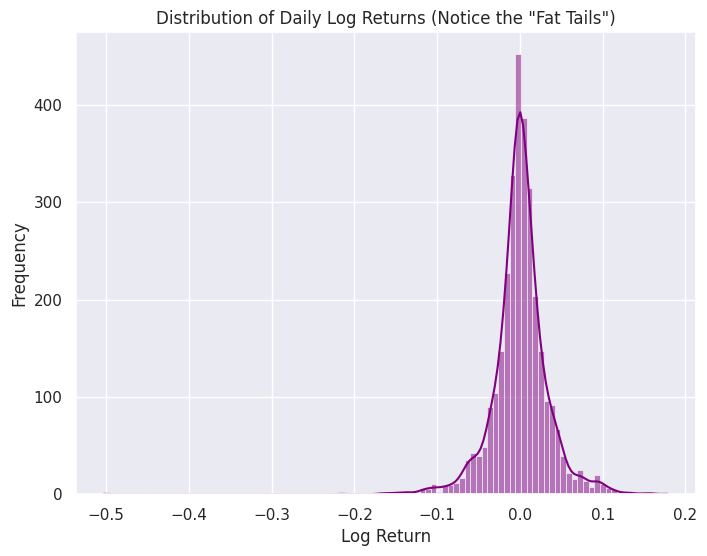

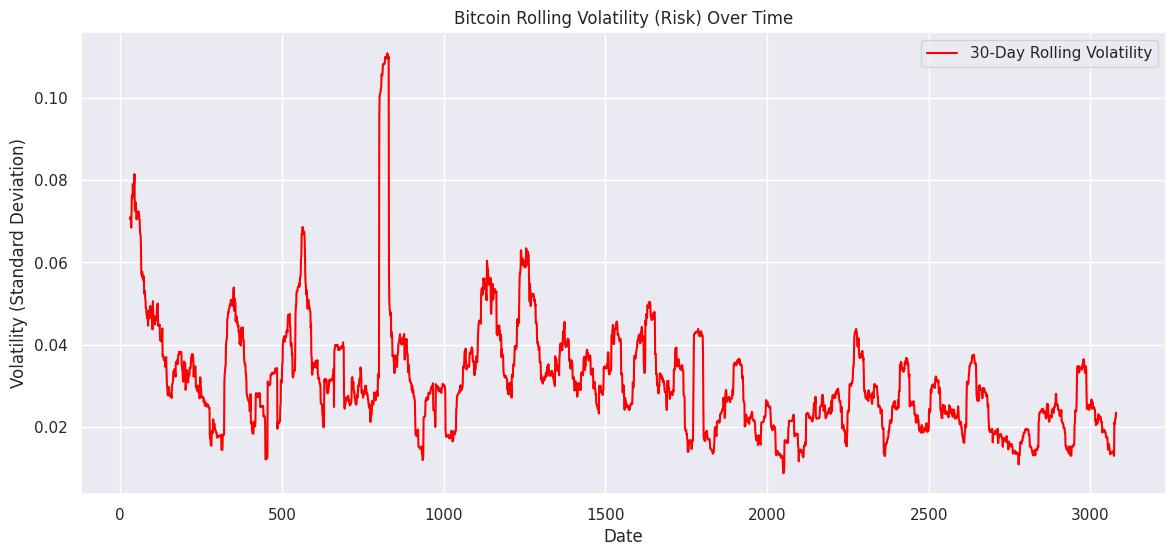

In [18]:
# Calculate Log Returns

df['Log Returns'] = np.log(df['Close'] / df['Close'].shift(1))

# --- Plot Distribution of Returns ---
plt.figure(figsize=(8, 6))
sns.histplot(df['Log Returns'].dropna(), bins=100, kde=True, color='purple')
plt.title('Distribution of Daily Log Returns (Notice the "Fat Tails")')
plt.xlabel('Log Return')
plt.ylabel('Frequency')
plt.show()

# Calculate & Plot 30-Day Rolling Volatility

df['Rolling Vol 30'] = df['Log Returns'].rolling(window=30).std()

plt.figure(figsize=(14, 6))
plt.plot(df.index, df['Rolling Vol 30'], color='red', label='30-Day Rolling Volatility')
plt.title('Bitcoin Rolling Volatility (Risk) Over Time')
plt.xlabel('Date')
plt.ylabel('Volatility (Standard Deviation)')
plt.legend()
plt.show()

Volume & Liquidity Analysis

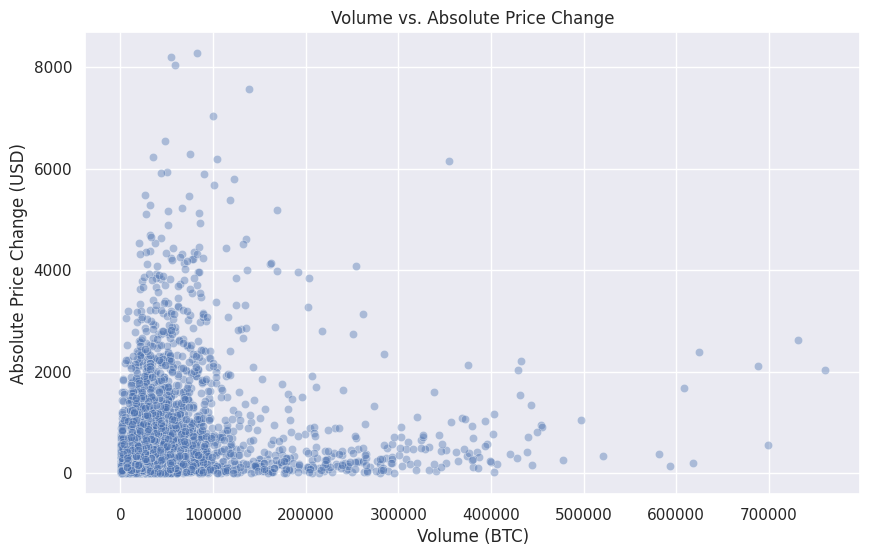

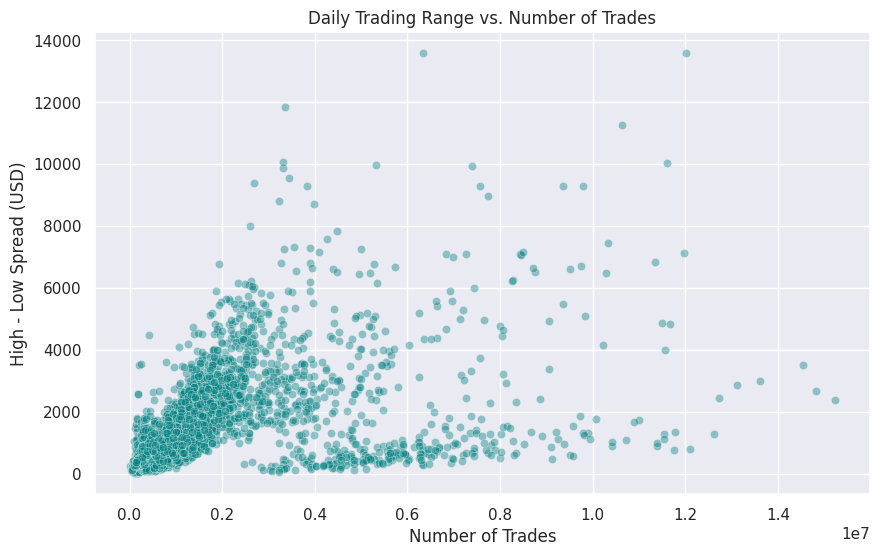

In [19]:
# Absolute price change for the period
df['Abs Price Change'] = abs(df['Close'] - df['Open'])

# The total spread from absolute top to bottom of the wick
df['High Low Spread'] = df['High'] - df['Low']

# Volume vs Absolute Price Change Correlation
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Volume', y='Abs Price Change', data=df, alpha=0.4)
plt.title('Volume vs. Absolute Price Change')
plt.xlabel('Volume (BTC)')
plt.ylabel('Absolute Price Change (USD)')
plt.show()

# High/Low spread vs no. of Trades
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Number of trades', y='High Low Spread', data=df, alpha=0.4, color='teal')
plt.title('Daily Trading Range vs. Number of Trades')
plt.xlabel('Number of Trades')
plt.ylabel('High - Low Spread (USD)')
plt.show()

Market Sentiment (Taker Data Analysis)

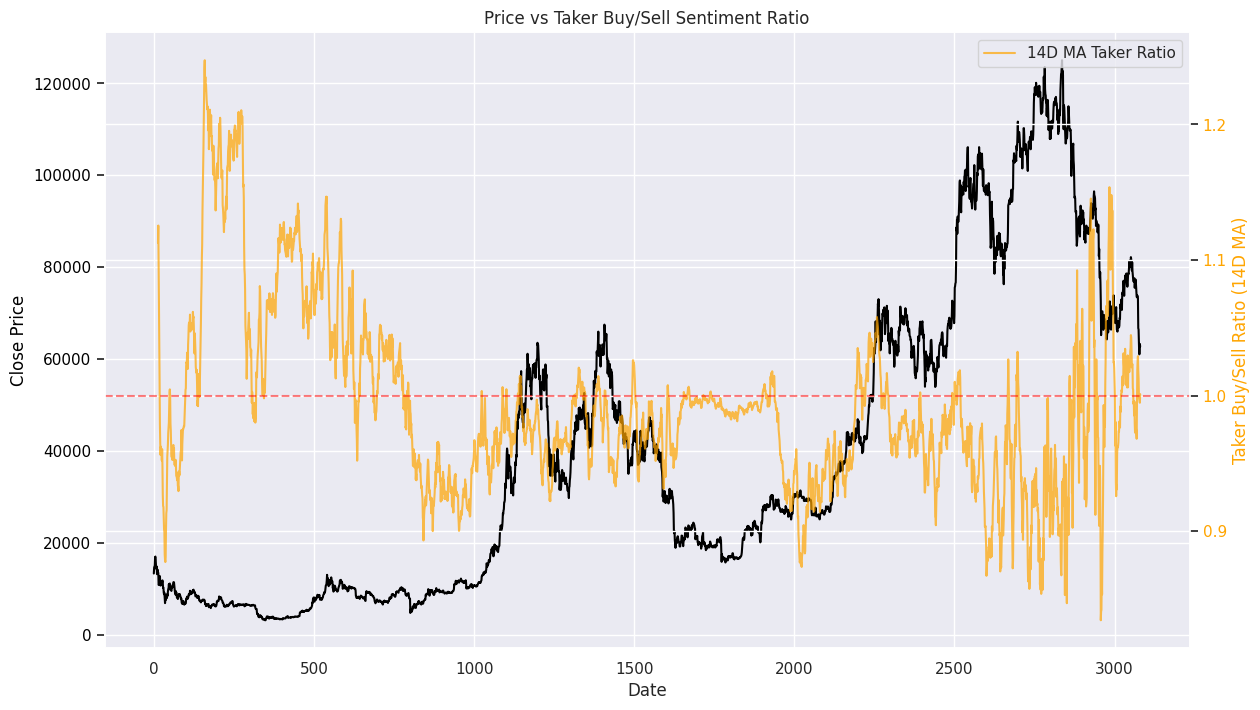

In [20]:
# Calculate Taker Sell Volume and Ratio

# Total Volume - Taker Buy Volume = Taker Sell Volume
df['Taker sell base asset volume'] = df['Volume'] - df['Taker buy base asset volume']

df['Taker Buy Sell Ratio'] = df['Taker buy base asset volume'] / (df['Taker sell base asset volume'] + 0.0001)

# Divergence Plot: Price vs Taker Ratio
fig, ax1 = plt.subplots(figsize=(14, 8))


ax1.plot(df.index, df['Close'], color='black', label='Close Price')
ax1.set_xlabel('Date')
ax1.set_ylabel('Close Price', color='black')
ax1.tick_params(axis='y', labelcolor='black')

ax2 = ax1.twinx()
# Applying a 14-day moving average to smooth the ratio for better visual divergence
ax2.plot(df.index, df['Taker Buy Sell Ratio'].rolling(window=14).mean(), color='orange', alpha=0.7, label='14D MA Taker Ratio')
ax2.set_ylabel('Taker Buy/Sell Ratio (14D MA)', color='orange')
ax2.tick_params(axis='y', labelcolor='orange')
ax2.axhline(1.0, color='red', linestyle='--', alpha=0.5) # Baseline where Buy = Sell

plt.title('Price vs Taker Buy/Sell Sentiment Ratio')
plt.legend()
plt.show()

Anomaly Detection (Flash Crashes)

Detected 26 potential flash crash/liquidation events.


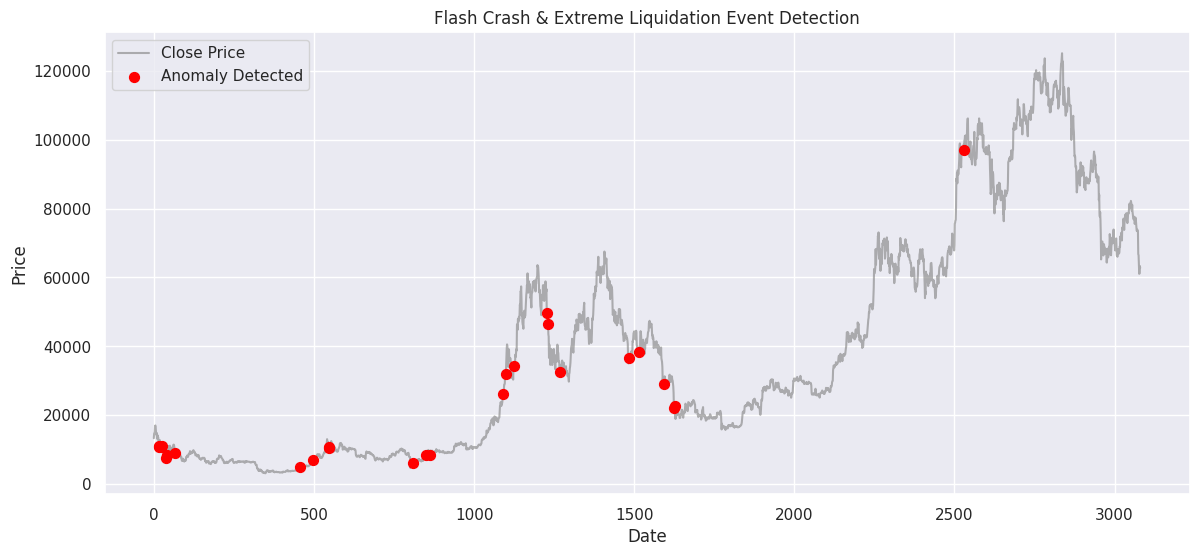

,Open,High,Low,Close,High Low Spread
16,10899.99,11680.99,9037.94,10988.79,2643.05
17,10972.59,11878.82,10435.33,10961.97,1443.49
22,10760.05,11399.00,9905.00,10799.18,1494.00
25,11184.70,11643.00,10311.15,11089.00,1331.85
37,7655.02,8476.00,7150.01,7599.00,1325.99
40,8683.93,9065.78,8120.00,8533.98,945.78
67,9267.07,9410.00,8329.00,9227.00,1081.00
457,4857.19,5275.01,4753.50,4932.60,521.51
496,7076.24,7521.78,6750.00,6967.31,771.78
546,10854.10,11282.28,10030.00,10624.93,1252.28


In [21]:
# Define Flash Crash Conditions
# Condition 1: Massive spread (e.g. High-Low spread is greater than 10% of the Open price)
massive_spread = df['High Low Spread'] > (df['Open'] * 0.10)

# Condition 2: Small real body (The difference between Open and Close is less than 20% of the total High-Low spread)
small_body = abs(df['Close'] - df['Open']) < (df['High Low Spread'] * 0.20)

# Filter dataframe for anomalies
flash_crashes = df[massive_spread & small_body]

print(f"Detected {len(flash_crashes)} potential flash crash/liquidation events.")

# Visualize Anomalies
plt.figure(figsize=(14, 6))
plt.plot(df.index, df['Close'], color='gray', label='Close Price', alpha=0.6)

# Overlay the anomalies as red dots
plt.scatter(flash_crashes.index, flash_crashes['Close'], color='red', s=50, label='Anomaly Detected', zorder=5)

plt.title('Flash Crash & Extreme Liquidation Event Detection')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.show()

# Display the dates and stats of the anomalies
display(flash_crashes[['Open', 'High', 'Low', 'Close', 'High Low Spread']])

In [22]:
!pip install ta

  Preparing metadata (setup.py) ... done
  Created wheel for ta: filename=ta-0.11.0-py3-none-any.whl size=29412 sha256=de5db6765020c587be07d3d08d96cd68e48c9c26b27ea328814a8b3f587a6872
  Stored in directory: /root/.cache/pip/wheels/5c/a1/5f/c6b85a7d9452057be4ce68a8e45d77ba34234a6d46581777c6
Successfully built ta


In [23]:

import ta

# Calculate Relative Strength Index (RSI)
df['RSI'] = ta.momentum.RSIIndicator(df['Close'], window=14).rsi()

# Calculate Moving Average Convergence Divergence (MACD)
df['MACD'] = ta.trend.MACD(df['Close']).macd()
df['MACD_Signal'] = ta.trend.MACD(df['Close']).macd_signal()

# Calculate Bollinger Bands
bb = ta.volatility.BollingerBands(df['Close'], window=20, window_dev=2)
df['BB_Middle'] = bb.bollinger_mavg()
df['BB_Upper'] = bb.bollinger_hband()
df['BB_Lower'] = bb.bollinger_lband()
df['BB_Width'] = bb.bollinger_wband()

print("Technical indicators (RSI, MACD, Bollinger Bands) added to the DataFrame.")
print("New columns added:", ['RSI', 'MACD', 'MACD_Signal', 'BB_Middle', 'BB_Upper', 'BB_Lower', 'BB_Width'])

# Display the head of the DataFrame with new indicators
display(df.tail())

Technical indicators (RSI, MACD, Bollinger Bands) added to the DataFrame.
New columns added: ['RSI', 'MACD', 'MACD_Signal', 'BB_Middle', 'BB_Upper', 'BB_Lower', 'BB_Width']


,Open time,Open,High,Low,Close,Volume,Quote asset volume,Number of trades,Taker buy base asset volume,Taker buy quote asset volume,...,High Low Spread,Taker sell base asset volume,Taker Buy Sell Ratio,RSI,MACD,MACD_Signal,BB_Middle,BB_Upper,BB_Lower,BB_Width
3076,2026-06-04,64142.75,64764.32,61383.56,63885.99,43577.17571,2.759350e+09,9057976,20172.82504,1.278142e+09,...,3380.76,23404.35067,0.861926,18.120501,-2728.358119,-1472.178032,74335.8620,82292.043040,66379.680960,21.406037
3077,2026-06-05,63885.99,63978.00,59130.91,61056.47,55027.28807,3.379022e+09,11658856,24879.51775,1.529682e+09,...,4847.09,30147.77032,0.825252,15.400959,-3341.720435,-1846.086513,73481.2830,83111.521345,63851.044655,26.211405
3078,2026-06-06,61056.47,61530.05,59500.00,61172.00,7449.05725,4.513838e+08,2065215,3788.76133,2.296707e+08,...,2030.05,3660.29592,1.035097,15.955586,-3774.976603,-2231.864531,72666.9995,83494.308445,61839.690555,29.799796
3079,2026-06-07,60884.62,64234.68,60746.00,63332.01,26612.10443,1.656651e+09,4752461,14156.31067,8.824907e+08,...,3488.68,12455.79376,1.136524,25.755964,-3899.094153,-2565.310455,71983.5065,83342.738587,60624.274413,31.560652
3080,2026-06-08,63332.01,63863.06,62657.07,62762.00,3880.86282,2.453209e+08,1123055,1934.33107,1.223898e+08,...,1205.99,1946.53175,0.993732,24.929804,-3997.374009,-2851.723166,71279.8885,83084.672315,59475.104685,33.122341


# Model Training

In [78]:
import numpy as np
from sklearn.preprocessing import MinMaxScaler


# Define the new set of features including technical indicators
features = [
    'Open', 'High', 'Low', 'Close', 'Volume',
    'RSI', 'MACD', 'MACD_Signal',
    'BB_Middle', 'BB_Upper', 'BB_Lower', 'BB_Width'
]


df_model = df[features].dropna().copy()

close_idx = features.index('Close')

data_model = df_model.values

scaler_X = MinMaxScaler(feature_range=(0, 1))
scaler_y = MinMaxScaler(feature_range=(0, 1))

# Scale the features (X)
scaled_data = scaler_X.fit_transform(data_model)
# Scale the target (y - 'Close' price)
scaled_target = scaler_y.fit_transform(data_model[:, close_idx].reshape(-1, 1))


def create_sequences(dataset, target, n_steps_in):
    X, y = [], []
    for i in range(len(dataset) - n_steps_in):
        X.append(dataset[i:(i + n_steps_in)])
        y.append(target[i + n_steps_in])
    return np.array(X), np.array(y)

n_steps_in = 30 # Number of previous time steps to use as input features
X, y = create_sequences(scaled_data, scaled_target, n_steps_in)

# Train-Test Split (Chronological for time series)
train_size = int(len(X) * 0.8)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

# Explicitly define n_features here to ensure it's correct for model building
n_features = len(features)

print(f"Updated X_train shape: {X_train.shape} (Samples, Time Steps, Features)")
print(f"Number of features used: {len(features)}")
print(f"Explicitly set n_features: {n_features}")

Updated X_train shape: (2414, 30, 12) (Samples, Time Steps, Features)
Number of features used: 12
Explicitly set n_features: 12


In [102]:
n_features = X_train.shape[2]

input_layer = Input(shape=(n_steps_in, n_features))
lstm_layer = LSTM(128, activation='relu', return_sequences=False)(input_layer)
middle_layer = Dense(64, activation='relu')(lstm_layer)
dropout = Dropout(0.2)(middle_layer)
output_layer = Dense(1, activation='linear')(dropout)

lstm_model = Model(inputs=input_layer, outputs=output_layer)
lstm_model.compile(optimizer=Adam(learning_rate=0.0005), loss='mse')

# Print model summary to confirm input shape
print("LSTM Model Input Shape:", lstm_model.input_shape)

from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    min_lr=1e-5
)

history = lstm_model.fit(
    X_train, y_train,
    epochs=200,
    batch_size=64,
    validation_split=0.2,
    verbose=1,
    callbacks=[early_stopping, reduce_lr]
)

LSTM Model Input Shape: (None, 30, 12)
Epoch 1/200
31/31 ━━━━━━━━━━━━━━━━━━━━ 7s 87ms/step - loss: 0.0128 - val_loss: 0.0013 - learning_rate: 5.0000e-04
Epoch 2/200
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0018 - val_loss: 6.8138e-04 - learning_rate: 5.0000e-04
Epoch 3/200
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0013 - val_loss: 0.0011 - learning_rate: 5.0000e-04
Epoch 4/200
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0011 - val_loss: 8.5306e-04 - learning_rate: 5.0000e-04
Epoch 5/200
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0010 - val_loss: 4.2246e-04 - learning_rate: 5.0000e-04
Epoch 6/200
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 8.5786e-04 - val_loss: 3.9027e-04 - learning_rate: 5.0000e-04
Epoch 7/200
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0010 - val_loss: 5.5143e-04 - learning_rate: 5.0000e-04
Epoch 8/200
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 7.9370e-04 - val_loss: 5.4598e-04 - learning_rate: 5.0000e-04
Epoch 9/200
31/31 ━━━━

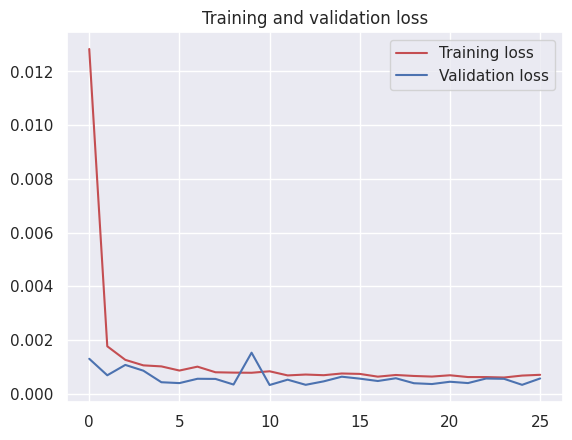

<Figure size 640x480 with 0 Axes>

In [103]:
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(len(loss))

plt.plot(epochs, loss, 'r', label='Training loss')
plt.plot(epochs, val_loss, 'b', label='Validation loss')
plt.title('Training and validation loss')
plt.legend(loc=0)
plt.figure()


plt.show()

In [104]:
current_date = df['Open time'].max()

# Calculate how many days are missing to reach June 9, 2026
target_date = pd.to_datetime('2026-06-09')
missing_days = (target_date - current_date).days

# Create future dates
future_dates = pd.date_range(start=current_date + pd.Timedelta(days=1), periods=missing_days)

# Extend df with future dates and NaN values for features
df_extended = df.copy()
for date in future_dates:
    df_extended = pd.concat([df_extended, pd.DataFrame([{'Open time': date}])], ignore_index=True)

# Forward fill and backward fill any NaNs created by extending the DataFrame
# This is a simple approach; for real-world, more sophisticated imputation might be needed.
df_extended = df_extended.ffill().bfill()

# Re-calculate technical indicators for the extended DataFrame
# Ensure 'Close' is not NaN after ffill/bfill before calculating indicators

df_extended['RSI'] = ta.momentum.RSIIndicator(df_extended['Close'], window=14).rsi()
df_extended['MACD'] = ta.trend.MACD(df_extended['Close']).macd()
df_extended['MACD_Signal'] = ta.trend.MACD(df_extended['Close']).macd_signal()

bb_extended = ta.volatility.BollingerBands(df_extended['Close'], window=20, window_dev=2)
df_extended['BB_Middle'] = bb_extended.bollinger_mavg()
df_extended['BB_Upper'] = bb_extended.bollinger_hband()
df_extended['BB_Lower'] = bb_extended.bollinger_lband()
df_extended['BB_Width'] = bb_extended.bollinger_wband()

# Drop rows with NaN values resulting from indicator calculation, especially at the beginning
df_extended = df_extended.dropna().reset_index(drop=True)

# Prepare df_for_prediction using the same features as df_model
df_for_prediction = df_extended[features].copy()

print(f"df_for_prediction shape after extending and recalculating indicators: {df_for_prediction.shape}")
print(f"Last 5 rows of df_for_prediction:\n{df_for_prediction.tail()}")


df_for_prediction shape after extending and recalculating indicators: (3049, 12)
Last 5 rows of df_for_prediction:
          Open      High       Low     Close       Volume        RSI  \
3044  63885.99  63978.00  59130.91  61056.47  55027.28807  15.400959   
3045  61056.47  61530.05  59500.00  61172.00   7449.05725  15.955586   
3046  60884.62  64234.68  60746.00  63332.01  26612.10443  25.755964   
3047  63332.01  63863.06  62657.07  62762.00   3880.86282  24.929804   
3048  63332.01  63863.06  62657.07  62762.00   3880.86282  24.929804   

             MACD  MACD_Signal   BB_Middle      BB_Upper      BB_Lower  \
3044 -3341.720435 -1846.086513  73481.2830  83111.521345  63851.044655   
3045 -3774.976603 -2231.864531  72666.9995  83494.308445  61839.690555   
3046 -3899.094153 -2565.310455  71983.5065  83342.738587  60624.274413   
3047 -3997.374009 -2851.723166  71279.8885  83084.672315  59475.104685   
3048 -4028.819777 -3087.142488  70540.3770  82532.367795  58548.386205   

       

In [105]:
# --- Prediction for June 9, 2026 (Standalone LSTM) ---

# 1. Scale the `df_for_prediction` using the already fitted scaler_X
scaled_data_for_prediction = scaler_X.transform(df_for_prediction.values)

# 2. Get the very last `n_steps_in` days from this newly scaled dataset
last_n_days = scaled_data_for_prediction[-n_steps_in:]

# Reshape it to (1, n_steps_in, n_features) to match the expected input shape for the LSTM model
last_n_days_reshaped = np.expand_dims(last_n_days, axis=0)

# Standalone LSTM Model Prediction for June 9th
predicted_scaled_price_lstm_solo = lstm_model.predict(last_n_days_reshaped, verbose=0)
predicted_price_june_9_lstm_solo = scaler_y.inverse_transform(predicted_scaled_price_lstm_solo.reshape(-1, 1))

print("==================================================")
print(f"STANDALONE LSTM MODEL PREDICTION FOR JUNE 9, 2026: ${predicted_price_june_9_lstm_solo[0][0]:.2f}")
print("==================================================\n")

# --- Calculate MAPE on the Test Set for Standalone LSTM Model ---
print('Evaluating Standalone LSTM Model on Test Set for MAPE:')

# Ensure y_actual is correctly inverse transformed from y_test
y_actual = scaler_y.inverse_transform(y_test)

# Standalone LSTM Model MAPE
y_pred_scaled_lstm_test = lstm_model.predict(X_test, verbose=0)
y_pred_lstm_test = scaler_y.inverse_transform(y_pred_scaled_lstm_test.reshape(-1, 1))
mape_lstm = mean_absolute_percentage_error(y_actual, y_pred_lstm_test) * 100
print(f"Standalone LSTM Test MAPE: {mape_lstm:.4f}%")

STANDALONE LSTM MODEL PREDICTION FOR JUNE 9, 2026: $60800.23

Evaluating Standalone LSTM Model on Test Set for MAPE:
Standalone LSTM Test MAPE: 2.9016%


###Hybrid Model Performance on Test Set

In [101]:
# Create a sub-model that outputs the hidden state of the LSTM layer
feature_extractor = Model(inputs=lstm_model.input, outputs=lstm_model.layers[1].output)

# Extract the temporal features for both train and test sets
z_train = feature_extractor.predict(X_train)
z_test = feature_extractor.predict(X_test)

print(f"Extracted LSTM feature shape: {z_train.shape}")

# Train the XGBoost Regressor on the extracted features
xgb_model = xgb.XGBRegressor(
    n_estimators=100,
    learning_rate=0.05,
    max_depth=10,
    objective='reg:squarederror'
)

xgb_model.fit(z_train, y_train.ravel())

76/76 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
Extracted LSTM feature shape: (2414, 128)


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=True, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=10,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=100,
             n_jobs=None, num_parallel_tree=None, ...)

In [108]:
import optuna
from tensorflow.keras.backend import clear_session

def objective(trial):
    clear_session()

    # --- Hyperparameters for LSTM Model ---
    lstm_units = trial.suggest_int('lstm_units', 32, 256, step=32)
    dense_units = trial.suggest_int('dense_units', 16, 128, step=16)
    dropout_rate = trial.suggest_float('dropout_rate', 0.1, 0.4, step=0.1)
    lstm_learning_rate = trial.suggest_float('lstm_learning_rate', 1e-4, 5e-3, log=True)

    # --- Build LSTM Model ---
    input_layer = Input(shape=(n_steps_in, n_features))
    lstm_layer = LSTM(lstm_units, activation='relu', return_sequences=False)(input_layer)
    middle_layer = Dense(dense_units, activation='relu')(lstm_layer)
    dropout = Dropout(dropout_rate)(middle_layer)
    output_layer = Dense(1, activation='linear')(dropout)

    lstm_model_trial = Model(inputs=input_layer, outputs=output_layer)
    lstm_model_trial.compile(optimizer=Adam(learning_rate=lstm_learning_rate), loss='mse')

    # Reduce epochs for faster tuning, use early stopping
    early_stopping_trial = EarlyStopping(
        monitor='val_loss',
        patience=5, # Shorter patience for quicker trials
        restore_best_weights=True
    )
    reduce_lr_trial = ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=2,
        min_lr=1e-6
    )

    history_trial = lstm_model_trial.fit(
        X_train, y_train,
        epochs=50, # Reduced epochs for faster tuning
        batch_size=64,
        validation_split=0.2,
        verbose=0, # Suppress verbose output during tuning
        callbacks=[early_stopping_trial, reduce_lr_trial]
    )

    # --- Extract Features ---
    feature_extractor_trial = Model(inputs=lstm_model_trial.input, outputs=lstm_model_trial.layers[1].output)
    z_train_trial = feature_extractor_trial.predict(X_train, verbose=0)
    z_test_trial = feature_extractor_trial.predict(X_test, verbose=0)

    # --- Hyperparameters for XGBoost Model ---
    xgb_n_estimators = trial.suggest_int('xgb_n_estimators', 50, 200, step=50)
    xgb_max_depth = trial.suggest_int('xgb_max_depth', 3, 15, step=3)
    xgb_learning_rate = trial.suggest_float('xgb_learning_rate', 1e-2, 0.3, log=True)

    # --- Build and Train XGBoost Model ---
    xgb_model_trial = xgb.XGBRegressor(
        n_estimators=xgb_n_estimators,
        learning_rate=xgb_learning_rate,
        max_depth=xgb_max_depth,
        objective='reg:squarederror',
        n_jobs=-1 # Use all available cores
    )
    xgb_model_trial.fit(z_train_trial, y_train.ravel())

    # --- Evaluate Hybrid Model ---
    y_pred_scaled_hybrid_test_trial = xgb_model_trial.predict(z_test_trial)
    y_pred_hybrid_test_trial = scaler_y.inverse_transform(y_pred_scaled_hybrid_test_trial.reshape(-1, 1))

    # Recalculate y_actual as it might have been cleared
    y_actual_trial = scaler_y.inverse_transform(y_test)

    mape_hybrid_trial = mean_absolute_percentage_error(y_actual_trial, y_pred_hybrid_test_trial) * 100

    return mape_hybrid_trial

In [109]:
study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=50) # Run 50 trials

print("Number of finished trials: ", len(study.trials))
print("Best trial:")
trial = study.best_trial

print("  Value: ", trial.value)
print("  Params: ")
for key, value in trial.params.items():
    print(f"    {key}: {value}")

[I 2026-07-06 06:11:51,053] A new study created in memory with name: no-name-30169588-990a-4c88-904a-e203e3f6a13d
[I 2026-07-06 06:12:45,676] Trial 0 finished with value: 32.429605887699694 and parameters: {'lstm_units': 256, 'dense_units': 64, 'dropout_rate': 0.30000000000000004, 'lstm_learning_rate': 0.0007802108740016495, 'xgb_n_estimators': 200, 'xgb_max_depth': 15, 'xgb_learning_rate': 0.010664338546558806}. Best is trial 0 with value: 32.429605887699694.
[I 2026-07-06 06:13:01,258] Trial 1 finished with value: 45.05176743364145 and parameters: {'lstm_units': 256, 'dense_units': 128, 'dropout_rate': 0.2, 'lstm_learning_rate': 0.0008980329696520882, 'xgb_n_estimators': 50, 'xgb_max_depth': 9, 'xgb_learning_rate': 0.01688451892768965}. Best is trial 0 with value: 32.429605887699694.
[I 2026-07-06 06:13:19,727] Trial 2 finished with value: 26.835105439052782 and parameters: {'lstm_units': 256, 'dense_units': 80, 'dropout_rate': 0.30000000000000004, 'lstm_learning_rate': 0.00277448115

Number of finished trials:  50
Best trial:
  Value:  23.479223891132317
  Params: 
    lstm_units: 32
    dense_units: 80
    dropout_rate: 0.30000000000000004
    lstm_learning_rate: 0.0007900075526297085
    xgb_n_estimators: 100
    xgb_max_depth: 3
    xgb_learning_rate: 0.094044095572493


In [110]:
# --- Prediction for June 9, 2026 (Hybrid Model) ---

# 1. Scale the `df_for_prediction` using the already fitted scaler_X
# This ensures the prediction data is scaled consistently with the training data
# `df_for_prediction` is already prepared with 12 features in `skTCPtx69_46`
scaled_data_for_prediction = scaler_X.transform(df_for_prediction.values)

# 2. Get the very last `n_steps_in` days from this newly scaled dataset
# This represents the sequence ending on June 8, 2026, with 12 features
last_n_days = scaled_data_for_prediction[-n_steps_in:]

# Reshape it to (1, n_steps_in, n_features) to match the expected input shape for the LSTM model
# where n_steps_in = 30 and n_features = 12
last_n_days_reshaped = np.expand_dims(last_n_days, axis=0)

# Hybrid Model Prediction for June 9th
# 3. Extract the temporal features using the trained LSTM feature_extractor
extracted_features_for_june_9 = feature_extractor.predict(last_n_days_reshaped, verbose=0)

# 4. Feed the features to XGBoost to get the final scaled prediction
predicted_scaled_price_hybrid = xgb_model.predict(extracted_features_for_june_9)

# 5. Inverse transform to get the actual USD value
predicted_price_june_9_hybrid = scaler_y.inverse_transform(predicted_scaled_price_hybrid.reshape(-1, 1))

print("==================================================")
print(f"HYBRID MODEL PREDICTION FOR JUNE 9, 2026: ${predicted_price_june_9_hybrid[0][0]:.2f}")
print("==================================================\n")

# --- Calculate MAPE on the Test Set for Hybrid Model ---
print('Evaluating Hybrid Model on Test Set for MAPE:')

# Ensure y_actual is correctly inverse transformed from y_test
y_actual = scaler_y.inverse_transform(y_test)

# Hybrid Model (LSTM + XGBoost) MAPE
# Use already computed z_test from q_kb_KwV7gYD
y_pred_scaled_hybrid_test = xgb_model.predict(z_test)
y_pred_hybrid_test = scaler_y.inverse_transform(y_pred_scaled_hybrid_test.reshape(-1, 1))
mape_hybrid = mean_absolute_percentage_error(y_actual, y_pred_hybrid_test) * 100
print(f"Hybrid (LSTM+XGBoost) Test MAPE: {mape_hybrid:.4f}%")

HYBRID MODEL PREDICTION FOR JUNE 9, 2026: $59644.07

Evaluating Hybrid Model on Test Set for MAPE:
Hybrid (LSTM+XGBoost) Test MAPE: 27.5695%
